## MULTI DATASET VECTORIZATION

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from gensim.models import FastText
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sentence_transformers import SentenceTransformer
from pathlib import Path

In [3]:
df_multi_clean = pd.read_csv("../../data/processed/multilingual_clean.csv")

In [4]:
X_multi = df_multi_clean['text_clean_classique'].fillna('').astype(str)
y_multi = df_multi_clean['sentiment'].fillna('neutral')
print(f"X_multi shape: {X_multi.shape}")
print(f"y_multi uniques: {y_multi.unique()}")

X_multi shape: (4500,)
y_multi uniques: <StringArray>
['positive', 'neutral', 'negative']
Length: 3, dtype: str


In [5]:
print('Vectorization Bag of Words')
bow_vectorizer = CountVectorizer(max_features=5000, min_df=2, max_df=0.8)
X_bow = bow_vectorizer.fit_transform(X_multi)
vocab_bow = len(bow_vectorizer.vocabulary_)
sparsity_bow = 1 - (X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]))
print(f"BoW done: vocab={vocab_bow}, shape={X_bow.shape}, sparsity={sparsity_bow*100:.2f}%")

Vectorization Bag of Words
BoW done: vocab=5000, shape=(4500, 5000), sparsity=99.74%


In [6]:
print('Vectorization TF-IDF')
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8, sublinear_tf=True, ngram_range=(1, 2))
X_tfidf = tfidf_vectorizer.fit_transform(X_multi)
vocab_tfidf = len(tfidf_vectorizer.vocabulary_)
sparsity_tfidf = 1 - (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))
print(f"TF-IDF done: vocab={vocab_tfidf}, shape={X_tfidf.shape}, sparsity={sparsity_tfidf*100:.2f}%")

Vectorization TF-IDF


TF-IDF done: vocab=5000, shape=(4500, 5000), sparsity=99.70%


In [7]:
comparison_df = pd.DataFrame({
    'Method': ['Bag of Words', 'TF-IDF'],
    'Vocab': [vocab_bow, vocab_tfidf],
    'Dims': [X_bow.shape[1], X_tfidf.shape[1]],
    'Sparsity (%)': [sparsity_bow*100, sparsity_tfidf*100]
})
print(comparison_df.to_markdown(index=False))

| Method       |   Vocab |   Dims |   Sparsity (%) |
|:-------------|--------:|-------:|---------------:|
| Bag of Words |    5000 |   5000 |        99.7443 |
| TF-IDF       |    5000 |   5000 |        99.6958 |


In [8]:
X_multi_light = df_multi_clean['text_clean_light'].fillna('').astype(str)
print('Training FastText...')
texts_tokenized = [text.split() for text in X_multi_light if text.strip()]
ft_model = FastText(sentences=texts_tokenized, vector_size=100, window=5, min_count=2, workers=4, epochs=10)
print(f"FastText vocab size: {len(ft_model.wv)}")

Training FastText...
FastText vocab size: 7419


In [9]:
print('Generating SBERT embeddings...')
sbert_path = Path("../../outputs/results/multi_sbert.npy")
if sbert_path.exists():
    X_sbert = np.load(sbert_path)
    print('Loaded SBERT from cache')
else:
    sentence_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    X_sbert = sentence_model.encode(X_multi.tolist(), batch_size=32, show_progress_bar=True, convert_to_numpy=True)
    print('Computed SBERT in memory')
print(f"SBERT shape: {X_sbert.shape}")

Generating SBERT embeddings...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/141 [00:00<?, ?it/s]

Computed SBERT in memory
SBERT shape: (4500, 384)


In [13]:
comparison_table = pd.DataFrame({
    'Method': ['BoW', 'TF-IDF', 'FastText', 'SBERT'],
    'Type': ['Symbolic', 'Statistical', 'Semantic (word)', 'Semantic (sentence)'],
    'Dims': [f'{X_bow.shape[1]}', f'{X_tfidf.shape[1]}', '100', f'{X_sbert.shape[1]}'],
    'Sparsity': [f'{sparsity_bow*100:.1f}%', f'{sparsity_tfidf*100:.1f}%', 'Dense', 'Dense']
})
print(comparison_table.to_markdown(index=False))

| Method   | Type                |   Dims | Sparsity   |
|:---------|:--------------------|-------:|:-----------|
| BoW      | Symbolic            |   5000 | 99.7%      |
| TF-IDF   | Statistical         |   5000 | 99.7%      |
| FastText | Semantic (word)     |    100 | Dense      |
| SBERT    | Semantic (sentence) |    384 | Dense      |


PCA 2D visualization...


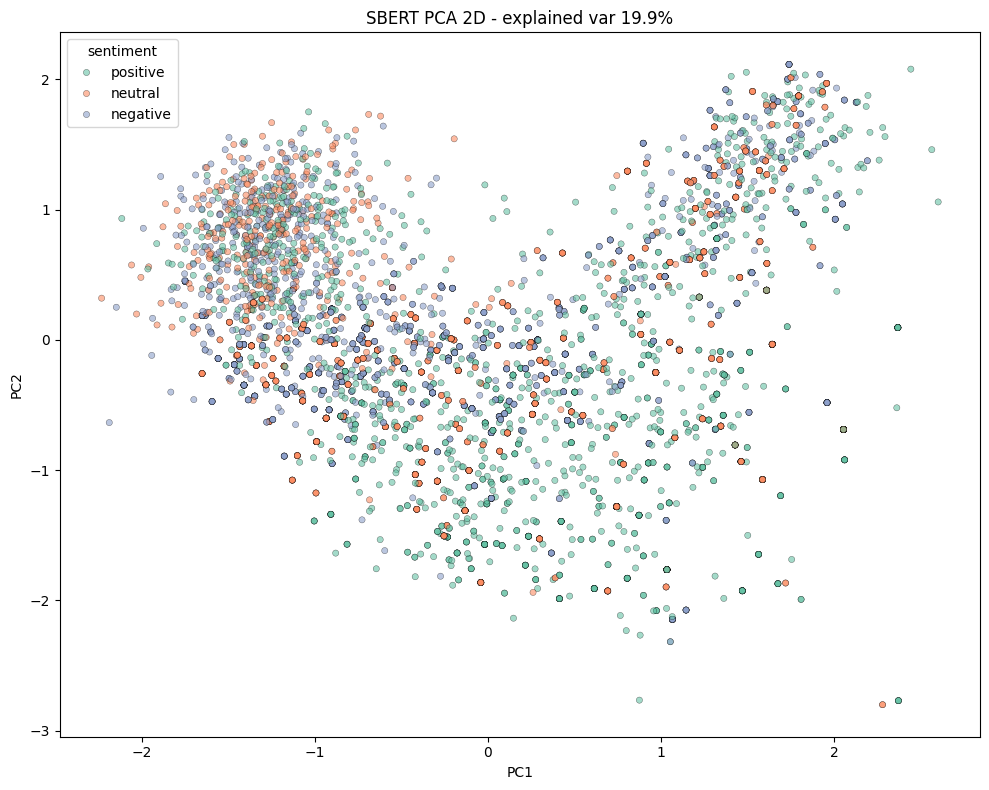

In [14]:
print('PCA 2D visualization...')
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sbert)
df_viz = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'sentiment': y_multi})
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_viz, x='PC1', y='PC2', hue='sentiment', palette='Set2', alpha=0.6, s=20, edgecolor='black', linewidth=0.3)
plt.title(f"SBERT PCA 2D - explained var {pca.explained_variance_ratio_.sum()*100:.1f}%")
plt.tight_layout()
plt.show()

In [15]:
print('Saving vectors...')
from scipy.sparse import save_npz
import pickle
save_npz("../../outputs/results/multi_tfidf.npz", X_tfidf)
with open("../../outputs/results/tfidf_vectorizer_multi.pkl", 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
np.save("../../outputs/results/multi_sbert.npy", X_sbert)
metadata = {
    'shape': X_sbert.shape,
    'sentiment_labels': y_multi.unique().tolist(),
    'model_name': 'paraphrase-multilingual-MiniLM-L12-v2'
}
with open("../../outputs/results/sbert_metadata_multi.pkl", 'wb') as f:
    pickle.dump(metadata, f)
print('Saved multi_tfidf, multi_sbert, and metadata')

Saving vectors...
Saved multi_tfidf, multi_sbert, and metadata
